# **Feature Engineering y Preparación para Modelado**

### Setup y Carga de Datos

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Instalación silenciosa de scikit-learn
!pip install scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Configuración visual
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar el dataset
try:
    df = pd.read_csv('manufacturing_defect_dataset.csv')

    # Exclusión por Data Leakage y relevancia (IE: Integridad del modelo)
    # DefectRate y QualityScore se excluyen por ser variables de resultado, no causas.
    cols_to_drop = ['DefectRate', 'QualityScore']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # 2. Crear id_proceso como identificador único
    df['id_proceso'] = df.index + 1

    # 3. Validación inicial
    print("--- SETUP Y VALIDACIÓN INICIAL ---")
    print(f"Dimensiones del dataset: {df.shape}")
    print(f"Valores nulos detectados: {df.isnull().sum().sum()}")
    print("\nTipos de datos seleccionados:")
    print(df.dtypes)

except FileNotFoundError:
    print("Error: Subir 'manufacturing_defect_dataset.csv' a la sesión de Colab.")

--- SETUP Y VALIDACIÓN INICIAL ---
Dimensiones del dataset: (3240, 16)
Valores nulos detectados: 0

Tipos de datos seleccionados:
ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
MaintenanceHours          int64
DowntimePercentage      float64
InventoryTurnover       float64
StockoutRate            float64
WorkerProductivity      float64
SafetyIncidents           int64
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
id_proceso                int64
dtype: object


### Análisis de Balance de Clases

--- ANÁLISIS DE BALANCE DE CLASES ---
Clase 0 (Conforme): 517 muestras (15.96%)
Clase 1 (Fuera de Spec): 2723 muestras (84.04%)


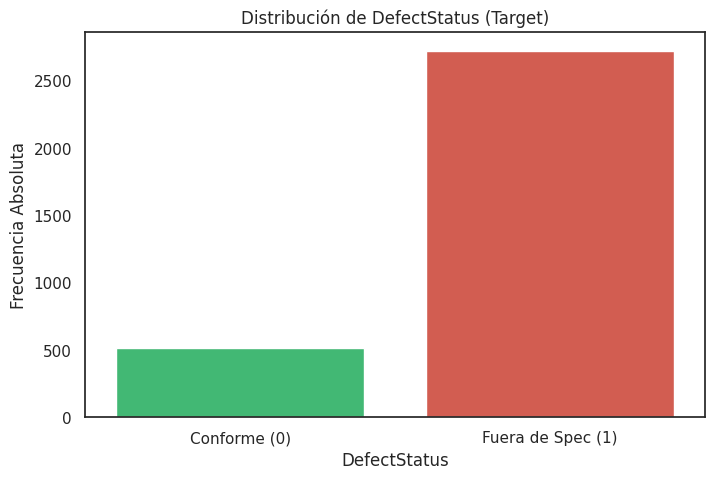


CONCLUSIÓN: El dataset está Balanceado.
ESTRATEGIA: La proporción de entrenamiento conservará aproximadamente el 84.04% de la clase 1.


In [2]:
# Conteo de la variable objetivo (0=Conforme, 1=Fuera de Spec)
counts = df['DefectStatus'].value_counts()
percent = df['DefectStatus'].value_counts(normalize=True) * 100

print(f"--- ANÁLISIS DE BALANCE DE CLASES ---")
print(f"Clase 0 (Conforme): {counts[0]} muestras ({percent[0]:.2f}%)")
print(f"Clase 1 (Fuera de Spec): {counts[1]} muestras ({percent[1]:.2f}%)")

# Visualización del balance
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title("Distribución de DefectStatus (Target)")
plt.xticks([0, 1], ['Conforme (0)', 'Fuera de Spec (1)'])
plt.ylabel("Frecuencia Absoluta")
plt.show()

# Conclusión basada en la proporción
is_balanced = "Balanceado" if (percent[1] > 40) else "Desbalanceado"
print(f"\nCONCLUSIÓN: El dataset está {is_balanced}.")
print(f"ESTRATEGIA: La proporción de entrenamiento conservará aproximadamente el {percent[1]:.2f}% de la clase 1.")

### Feature Engineering: 3 variables nuevas

In [3]:
print("--- GENERACIÓN DE FEATURES (INGENIERÍA INDUSTRIAL) ---")

# 1. Eficiencia económica del turno (IE: costo unitario de producción)
df['costo_por_unidad'] = df['ProductionCost'] / df['ProductionVolume']

# 2. Indicador binario de sobrecarga operativa (IE: turno de alta demanda)
# Se define como 1 si el volumen supera el tercer cuartil (P75)
p75_vol = df['ProductionVolume'].quantile(0.75)
df['alta_carga'] = (df['ProductionVolume'] > p75_vol).astype(int)

# 3. Intensidad energética por unidad (IE: proxy de eficiencia de maquinaria)
df['energia_por_unidad'] = df['EnergyConsumption'] / df['ProductionVolume']

# Estadísticas de las nuevas variables
nuevas_features = ['costo_por_unidad', 'alta_carga', 'energia_por_unidad']
display(df[nuevas_features].describe())

print(f"\nUmbral de 'Alta Carga' detectado en: {p75_vol:.2f} unidades.")

--- GENERACIÓN DE FEATURES (INGENIERÍA INDUSTRIAL) ---


,costo_por_unidad,alta_carga,energia_por_unidad
count,3240.000000,3240.00000,3240.000000
mean,32.056882,0.25000,7.770224
std,27.097178,0.43308,6.858100
min,5.166510,0.00000,1.053529
25%,15.144584,0.00000,3.487270
50%,22.695831,0.00000,5.454788
75%,37.887605,0.25000,9.333666
max,199.577353,1.00000,48.473202



Umbral de 'Alta Carga' detectado en: 775.25 unidades.


### Train/Test Split con Estratificación

In [4]:
# Lista final de variables predictoras
features_list = [
    'ProductionVolume', 'ProductionCost', 'SupplierQuality',
    'MaintenanceHours', 'DowntimePercentage', 'WorkerProductivity',
    'EnergyConsumption', 'costo_por_unidad', 'alta_carga', 'energia_por_unidad'
]

X = df[features_list]
y = df['DefectStatus']

# Dividir dataset (80% Train, 20% Test)
# Stratify=y asegura que la proporción de defectos sea la misma en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- DIVISIÓN DE DATOS (TRAIN/TEST SPLIT) ---")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# Verificación de Estratificación
p_train = (y_train.sum() / len(y_train)) * 100
p_test = (y_test.sum() / len(y_test)) * 100

print(f"\nVerificación de Stratify:")
print(f"  % Clase 1 en Train: {p_train:.2f}%")
print(f"  % Clase 1 en Test:  {p_test:.2f}%")

--- DIVISIÓN DE DATOS (TRAIN/TEST SPLIT) ---
X_train: (2592, 10) | X_test: (648, 10)

Verificación de Stratify:
  % Clase 1 en Train: 84.03%
  % Clase 1 en Test:  84.10%


### Distribución de Features por Clase

--- ANÁLISIS VISUAL DE PODER DISCRIMINATIVO ---


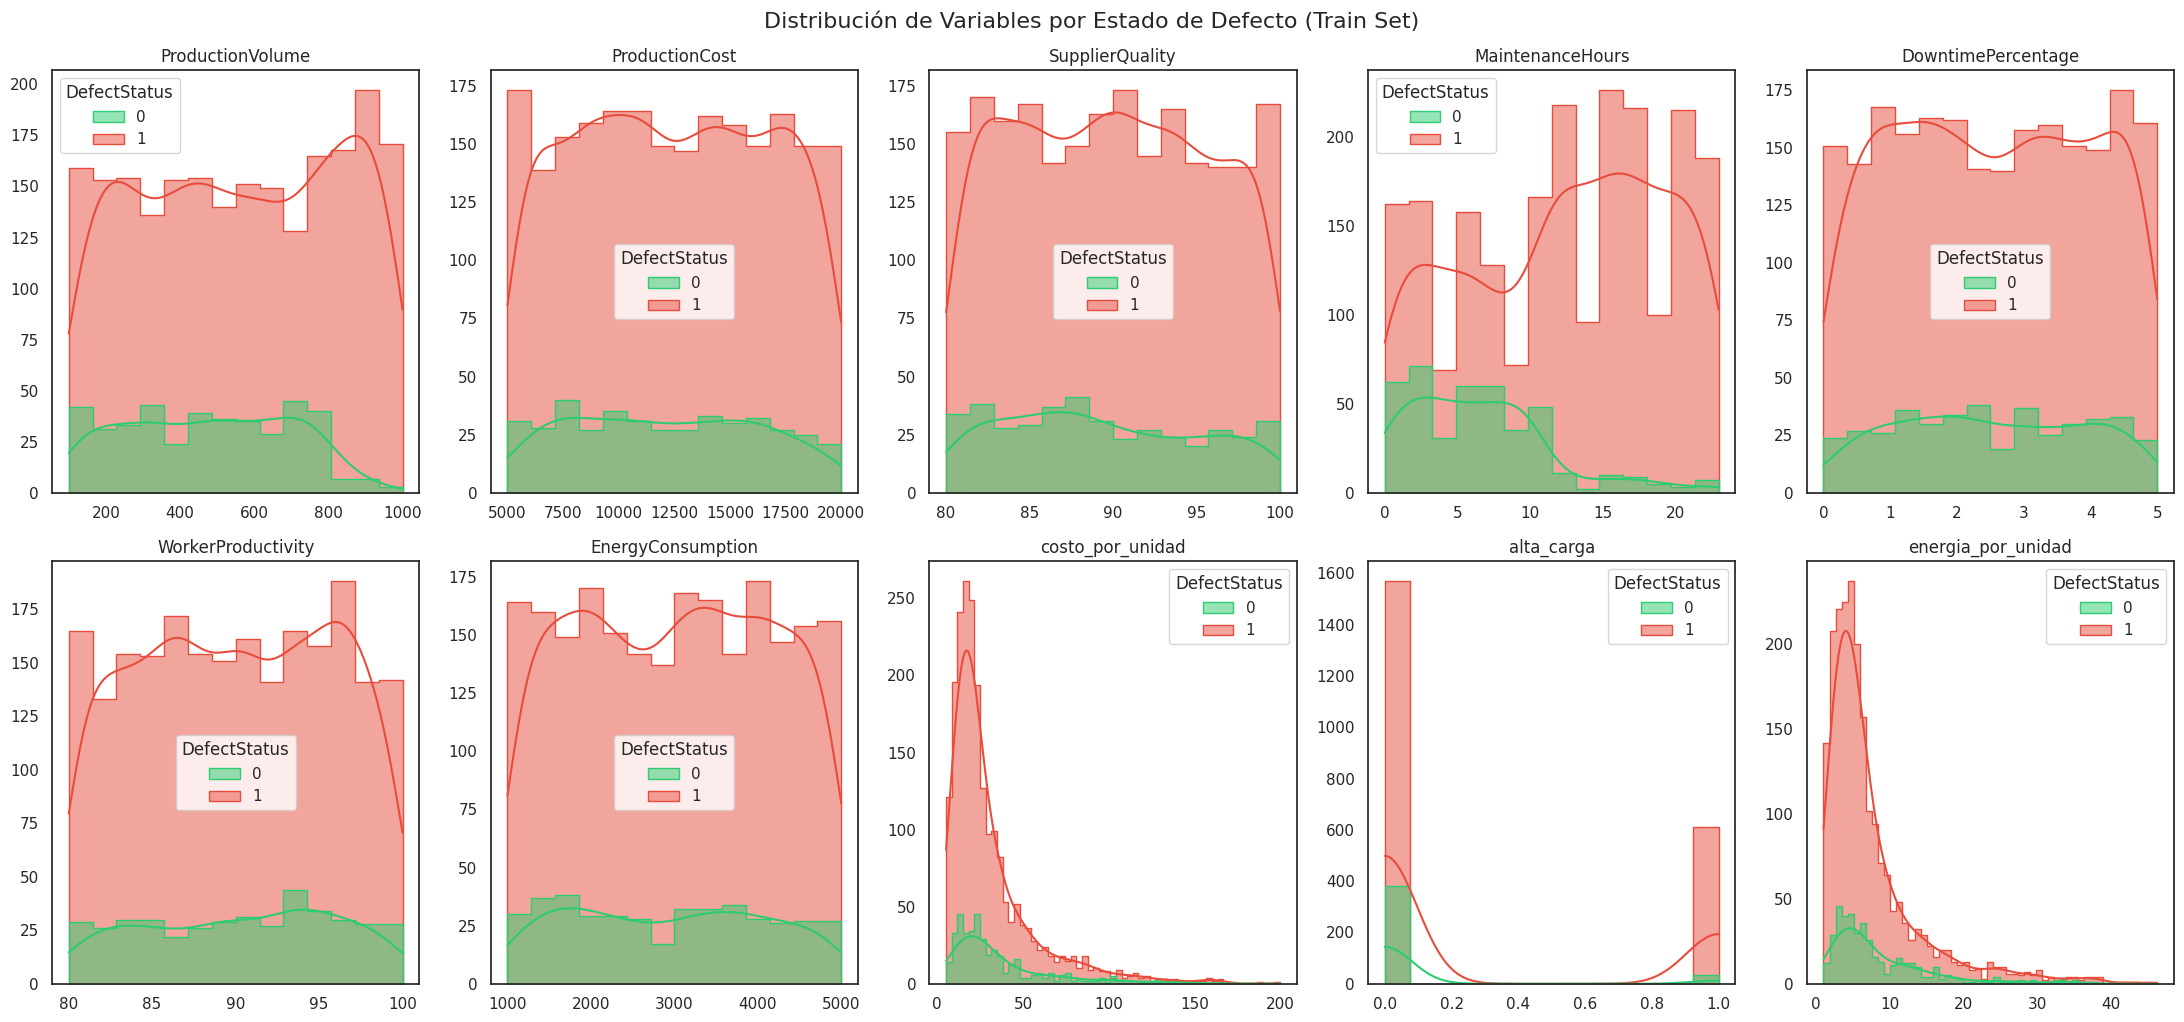


NOTA: Las variables con menor solapamiento entre curvas verde/roja son los mejores predictores.


In [5]:
print("--- ANÁLISIS VISUAL DE PODER DISCRIMINATIVO ---")

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(features_list):
    sns.histplot(data=X_train, x=col, hue=y_train, ax=axes[i],
                 kde=True, palette=['#2ecc71', '#e74c3c'], alpha=0.5, element="step")
    axes[i].set_title(f"{col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.suptitle("Distribución de Variables por Estado de Defecto (Train Set)", fontsize=16, y=1.02)
plt.show()

print("\nNOTA: Las variables con menor solapamiento entre curvas verde/roja son los mejores predictores.")

### Correlación Features vs Target

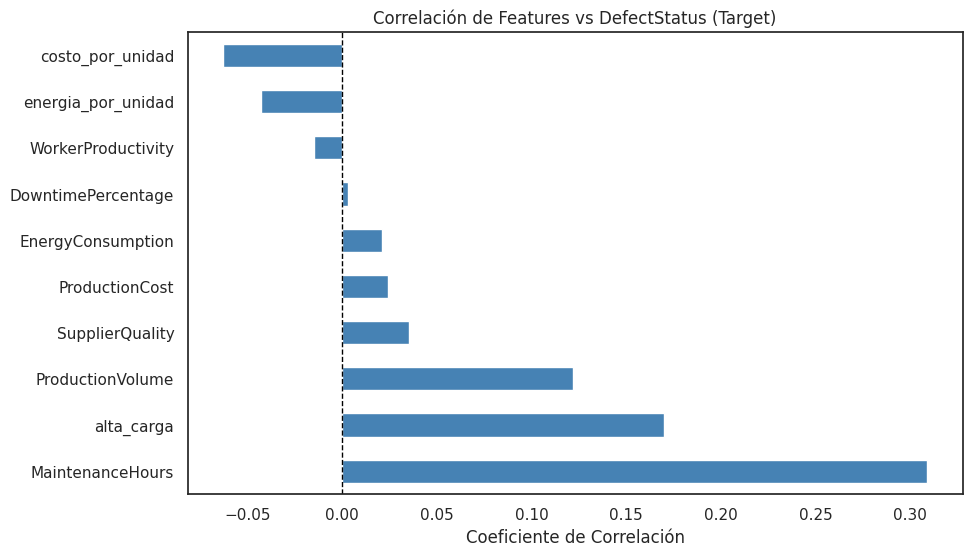

--- TOP 3 FEATURES CON MAYOR PODER PREDICTIVO ---
1. MaintenanceHours: 0.3091
2. alta_carga: 0.1700
3. ProductionVolume: 0.1218


In [6]:
# Calcular correlación de Pearson con el target
corrs = X_train.corrwith(y_train).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corrs.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Correlación de Features vs DefectStatus (Target)")
plt.xlabel("Coeficiente de Correlación")
plt.show()

top_3 = corrs.abs().sort_values(ascending=False).head(3)
print(f"--- TOP 3 FEATURES CON MAYOR PODER PREDICTIVO ---")
for i, (feat, val) in enumerate(top_3.items()):
    print(f"{i+1}. {feat}: {corrs[feat]:.4f}")

### Escalamiento con StandardScaler

In [9]:
# Guardar versiones originales (X_raw) antes de escalar para modelos basados en árboles
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

scaler = StandardScaler()

# IMPORTANTE: fit solo en X_train para evitar Data Leakage.
# Si hiciéramos fit en X_test, el modelo 'conocería' la media del futuro (test set).
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- RESULTADO DEL ESCALAMIENTO (StandardScaler) ---")
# Comparación para una feature (ej: ProductionCost)
idx_col = features_list.index('MaintenanceHours')
print(f"Variable: MaintenanceHours")
print(f"  Media Original: {X_train['MaintenanceHours'].mean():.2f}")
print(f"  Media Scaled (Train): {X_train_scaled[:, idx_col].mean():.2f} (Aprox 0)")
print(f"  Desviación Scaled: {X_train_scaled[:, idx_col].std():.2f} (Aprox 1)")

print("\nLos datasets 'X_train_scaled' y 'X_test_scaled' están listos para el modelado.")

--- RESULTADO DEL ESCALAMIENTO (StandardScaler) ---
Variable: MaintenanceHours
  Media Original: 11.42
  Media Scaled (Train): -0.00 (Aprox 0)
  Desviación Scaled: 1.00 (Aprox 1)

Los datasets 'X_train_scaled' y 'X_test_scaled' están listos para el modelado.


### Resumen de Ingeniería para ColPlásticos

**Exclusión de Variables:** DefectRate y QualityScore fueron eliminadas. Incluirlas sería un error de "Data Leakage", ya que en una línea de producción real, no conoces la tasa de defectos final antes de que ocurra el defecto que intentas predecir.

**Estratificación:** Al usar stratify=y, garantizamos que si la planta produce un 2% de defectos, tanto el entrenamiento como la prueba reflejen ese 2%. Esto evita que el modelo aprenda sesgos inexistentes.

**Nuevas Features:** Las variables de "costo por unidad" e "intensidad energética" son indicadores clave de rendimiento (KPIs). A menudo, una máquina que consume energía de forma ineficiente es síntoma de un desajuste mecánico que precede al defecto.

**Escalamiento:** Modelos como la Regresión Logística o SVM requieren que todas las variables estén en la misma escala para que el ProductionCost (miles de pesos) no "domine" sobre el DowntimePercentage (fracciones decimales) solo por su magnitud numérica.